PROBLEM
 scores
a) 1 
b) 1 
c) 3 

This is a __beta-alpha motif__ of an enzyme family 
absolutely necessary for its activity 

Try to answer:

a) Place the side-chains of this structure and name the model p11a.pdb
TEACHER WAY:
- PDBtoSplitChain.pl -i problem1 -o problem_1_ --> will obtain the fasta seq of the motif, like the ones I had obtained
- cat problem_1_A.fa > alignment.fa
- cat problem_1_A.fa >> alignment.fa
- clustalw alignment.fa
- aconvertMod2.pl -in c -out p <alignment.aln > alignment.pir
- cp /mnt/NFS_UPF/soft/modeller/examples/automodel/model-default.py  .
- modify the script and put alignment_pir, the structure is problem_1_A.pdb and in sequence = problem_1_A

Modeller doesn't just guess where atoms go; it uses Comparative Modeling (also called Homology Modeling). It follows these steps:

Reads the Alignment: It looks at your .pir file to see how your "mystery" sequence (the Target) matches up with a sequence that already has a known 3D shape (the Template).

Copies the "Skeleton": Where the sequences match, it copies the 3D coordinates from the Template's PDB file.

Satisfies Restraints: It uses a mathematical process called Spatial Restraint Satisfaction. It calculates the "ideal" distances and angles for the parts of your sequence that are different from the template.

Generates the Model: It outputs a new .pdb file containing the predicted 3D coordinates for your sequence.

```
>> Summary of successfully produced models:
Filename                          molpdf
----------------------------------------
problem_1_A.B99990001.pdb       73.39211
```
With the obtained file, we have predictes the side-chains!

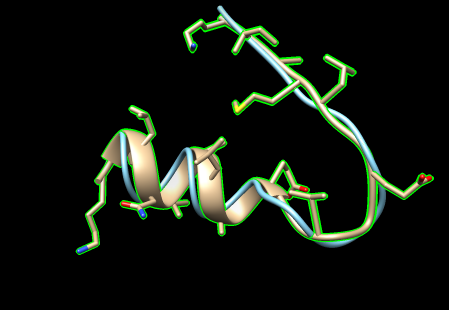


b) Find the protein(s) with this motif and hypothesize what's the function of the motif. Please demonstrate your hypothesis with a sequence alignment or p-values.

BUsco el perfil .hmm i després hmmsearch sobre una seq db per trobar homòlegs

```
jackhmmer --chkhmm p11a_profile p11a.fa /mnt/NFS_UPF/soft/databases/blastdat/uniprot_sprot.fasta
hmmsearch p11a_profile-1.hmm /mnt/NFS_UPF/soft/databases/blastdat/pdb_seq > p11a_pdb.out
```
Even though the E-values are slightly above the standard "highly significant" threshold (0.1 instead of < 0.001), the results are very consistent, which makes them highly reliable for a short motif of only 21 residues.
The top hits are all related to the Ras superfamily of small GTPases, specifically:

- RAP2A / RAP1A / Rap-1b: These are "Ras-related" proteins.

- GTPase HRas / Transforming protein P21/H-Ras: This is the classic Ras protein.

Domain annotation for each sequence (and alignments):
>> 1kao_A  mol:protein length:167  RAP2A
   #    score  bias  c-Evalue  i-Evalue hmmfrom  hmm to    alifrom  ali to    envfrom  env to     acc
 ---   ------ ----- --------- --------- ------- -------    ------- -------    ------- -------    ----
   1 ?   13.6   0.1   0.00021      0.29       1      19 [.       5      23 ..       5      25 .. 0.90

  Alignments for each domain:
  == domain 1  score: 13.6 bits;  conditional E-value: 0.00021
  P1;p11a  1 kiamlgeggvgeaaltvnl 19
             k+ +lg ggvg++altv +
   1kao_A  5 KVVVLGSGGVGKSALTVQF 23
             7899************975 PP

>> 2rap_A  mol:protein length:167  RAP2A
   #    score  bias  c-Evalue  i-Evalue hmmfrom  hmm to    alifrom  ali to    envfrom  env to     acc
 ---   ------ ----- --------- --------- ------- -------    ------- -------    ------- -------    ----
   1 ?   13.6   0.1   0.00021      0.29       1      19 [.       5      23 ..       5      25 .. 0.90

  Alignments for each domain:
  == domain 1  score: 13.6 bits;  conditional E-value: 0.00021
  P1;p11a  1 kiamlgeggvgeaaltvnl 19
             k+ +lg ggvg++altv +
   2rap_A  5 KVVVLGSGGVGKSALTVQF 23
             7899************975 PP


Notice the ***** underneath the GGVG stretch in the alignment. This indicates very high conservation. These glycines allow the protein backbone to wrap tightly around the phosphates of GTP.
In your query, you have an E (Glutamate) where the template has a K (Lysine). However, the match is close enough that HMMER identified it. In a functional Ras protein, that Lysine is what anchors the phosphate groups

c) Do you think this motif can still be functional
   To answer this question, show:
   1. What are the Aas that do the function. Have they been mutated?
   2. Obtain the structure of this motif bound to the ligand and name it p11c.pdb
      Make a JMOL/RASMOL image showing if the function can or cannot be done. Name the image p11c_fig1
   3. Calculate the statistic potential of the motif and align the profile with the profile of any homolog
      with known structure, as found in question "b"

d) Can you add the ATP or GDP (FER UN BLAST AMB LA SEQ DE ATP I VEUREM QUINES REGIONS INTERACTIUEN AMB AQUST P-LOOP)

blastp -query problem_1_A.fa -db /mnt/NFS_UPF/soft/databases/blastdat/pdb_seq -out problem_1.blastp 
gedit problem_1.blast (the e-values are really bad, )

```
chimera 1GUA.pdb problem_1_A.B99990001.pdb
```

open on chimera the superimposition and save the supeimposition with GDP in a pdb file. Unselect the whole structure, until you get the motif with the 

Select the Ligand: * Go to the Select menu > Residue > and choose your ligand’s name (e.g., GUA or its three-letter PDB code).

Invert the Selection:

Go to the Select menu and click Invert (all models).

Now, instead of the interaction zone, everything except your zone is highlighted.

Hide the Rest:

Go to Actions > Atoms/Bonds > hide.

Go to Actions > Ribbon > hide.


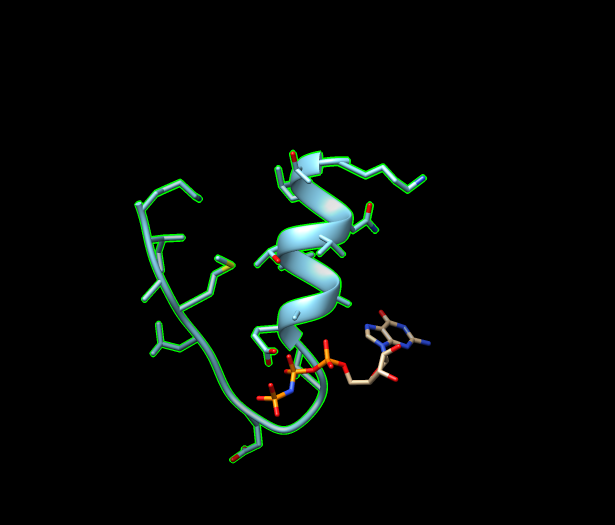


to know the residues of a function, we go to `database of active sites`on google, and in EMBL-BI there's a dataase of the catalityic sites, and just put the pdb and will know the relevant residues --> that's one way. If this residues have been substiuted, they won' work. The function has changed a lot? 


----------

MOTIF STRUCTURE

ATOM     85  CA  LYS A  13       4.882  49.566   2.107  1.00  8.46           C  
ATOM    107  CA  ILE A  14       7.654  47.392   3.489  1.00  7.31           C  
ATOM    126  CA  ALA A  15       9.004  44.166   1.995  1.00 11.62           C  
ATOM    136  CA  MET A  16      10.650  41.347   3.995  1.00 11.38           C  
ATOM    153  CA  LEU A  17      13.666  39.749   2.318  1.00  7.01           C  
ATOM    172  CA  GLY A  18      16.039  36.995   3.438  1.00  9.05           C  
ATOM    179  CA  GLU A  19      16.725  33.285   3.014  1.00  9.84           C  
ATOM    194  CA  GLY A  20      14.306  30.682   4.311  1.00 11.26           C  
ATOM    201  CA  GLY A  21      14.267  30.082   8.041  1.00 11.09           C  
ATOM    208  CA  VAL A  22      15.792  33.403   9.159  1.00  8.09           C  
ATOM    224  CA  GLY A  23      12.642  34.570  10.894  1.00 10.70           C  
ATOM    231  CA  GLU A  24      10.804  36.735   8.336  1.00  7.87           C  
ATOM    253  CA  ALA A  25       7.301  35.440   9.099  1.00  9.18           C  
ATOM    266  CA  ALA A  26       7.962  35.295  12.858  1.00  8.07           C  
ATOM    277  CA  LEU A  27       9.129  38.932  12.897  1.00  6.47           C  
ATOM    296  CA  THR A  28       6.090  40.121  10.939  1.00  8.96           C  
ATOM    310  CA  VAL A  29       3.572  38.142  13.022  1.00 10.37           C  
ATOM    326  CA  ASN A  30       5.213  39.452  16.196  1.00 11.86           C  
ATOM    340  CA  LEU A  31       5.254  43.058  14.993  1.00  6.76           C  
ATOM    359  CA  THR A  32       1.600  43.004  13.932  1.00 11.17           C  
ATOM    373  CA  LYS A  33       0.318  41.320  17.107  1.00 11.12           C  


